# 00 · Datos, limpieza y construcción del dataset

**Taller B5-T1 · Generación de datos financieros sinteticos**

Este notebook prepara la materia prima del proyecto. Recorre el camino completo
desde los precios históricos descargados de Yahoo Finance hasta el conjunto
supervisado que consumen todos los notebooks posteriores, y deja documentada
cada decisión de limpieza y de partición.

El problema que se plantea es la **anticipación de episodios de caída severa en
el mercado**: a partir de la ventana de rentabilidades de los últimos sesenta
días, determinar si la cartera sufrira un retroceso pronunciado durante los
treinta días siguientes. Se trata de un suceso poco frecuente por definición, lo
que convierte la escasez de ejemplos positivos en el obstaculo central y
justifica el recurso a la generación sintetica.

**Salida:** `data/processed/dataset.npz`, con las tres particiones ya escaladas,
la etiqueta binaria, las fechas de cada ventana y los parametros del escalador.

## Preparación del entorno

Se fija el backend de cómputo, se añade el código común del proyecto a la ruta
de importación y se aplica el estilo gráfico compartido. El bloque funciona sin
cambios tanto en una instalación local como en Colab.

In [1]:
import os
import sys

# Keras 3 se ejecuta sobre PyTorch: la versión de Python empleada no dispone de
# TensorFlow y la API de capas y modelos es idéntica en ambos backends.
os.environ["KERAS_BACKEND"] = "torch"

EN_COLAB = "google.colab" in sys.modules

if EN_COLAB:
    !pip install -q yfinance keras torch
    # En Colab se asume que el repositorio está clonado en el directorio actual.
    RAIZ = "/content/B5-T1"
else:
    RAIZ = os.path.dirname(os.getcwd())

if os.path.join(RAIZ, "src") not in sys.path:
    sys.path.insert(0, os.path.join(RAIZ, "src"))

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from miax_b5t1 import config, datos, experimento, graficos, modelo

graficos.aplicar_estilo()
config.asegurar_directorios()

print(f"Keras {keras.__version__} sobre backend {keras.backend.backend()}")
print(f"Raíz del proyecto: {RAIZ}")

Keras 3.15.1 sobre backend torch
Raíz del proyecto: C:\Users\raulr\Documents\MIAX\Practicas\B5-T1


## 1. Origen de los datos

Se parte de la lista de componentes del S&P 500 y de sus precios de cierre
ajustados por dividendos y splits. La descarga se realiza una única vez mediante
`scripts/descargar_precios.py` y queda almacenada en `data/raw/`, de modo que la
ejecución del notebook no depende de la disponibilidad del servicio externo ni
introduce variaciones entre ejecuciones.

In [2]:
ruta_raw = config.RUTA_PRECIOS_RAW
print(f"Cache de precios: {ruta_raw}")
print(f"Tamaño en disco: {os.path.getsize(ruta_raw) / 1e6:.1f} MB")

precios_completo = pd.read_csv(ruta_raw, index_col=0, parse_dates=True)

print(f"\nMatriz descargada: {precios_completo.shape[0]} sesiones x "
      f"{precios_completo.shape[1]} tickers")
print(f"Periodo cubierto: {precios_completo.index.min().date()} a "
      f"{precios_completo.index.max().date()}")
print(f"Porcentaje global de valores ausentes: "
      f"{100 * precios_completo.isna().mean().mean():.1f} %")

Cache de precios: C:\Users\raulr\Documents\MIAX\Practicas\B5-T1\data\raw\precios_close_sp500.csv
Tamaño en disco: 83.4 MB



Matriz descargada: 16271 sesiones x 503 tickers
Periodo cubierto: 1962-01-02 a 2026-08-26
Porcentaje global de valores ausentes: 47.0 %


## 2. Selección del universo y sesgo de supervivencia

La matriz descargada esta densamente poblada de huecos: la mayor parte de las
companias que hoy integran el índice no cotizaban en los años sesenta. Se opta
por conservar únicamente las series con historia completa en todo el periodo, lo
que elimina la necesidad de imputar valores y garantiza que la matriz de
covarianzas se estime siempre sobre el mismo conjunto de activos.

La contrapartida es un **sesgo de supervivencia** evidente: el universo
resultante esta formado por companias que han permanecido cotizadas durante seis
decadas, de perfil más estable que el del índice completo. El sesgo afecta al
nivel absoluto de rentabilidad esperada, pero no invalida el ejercicio, ya que
el objeto de estudio es la comparación entre modelos generativos sobre unos
mismos datos y no la estimación de una prima de riesgo.

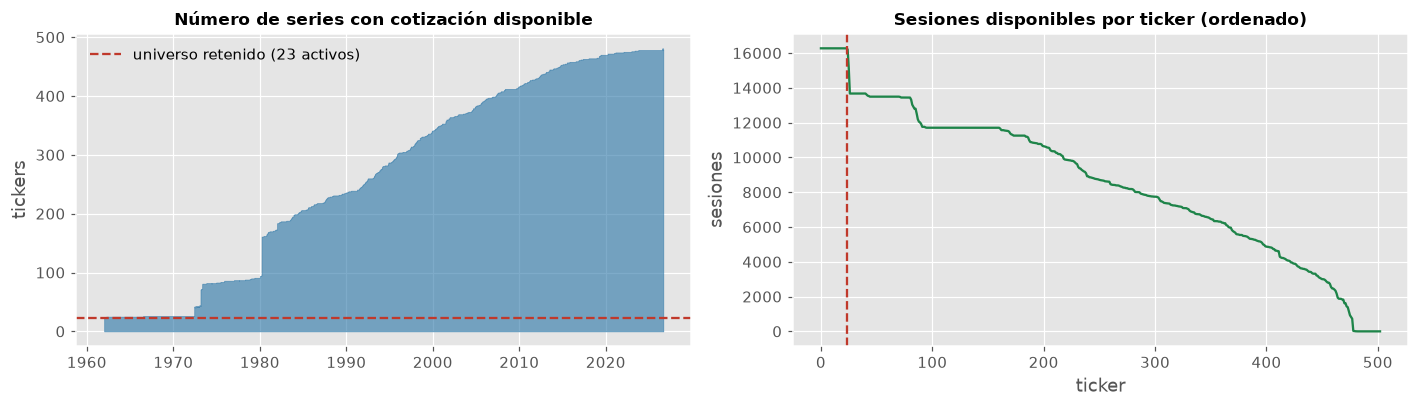

Tickers descargados: 503
Tickers con historia completa: 23


In [3]:
cobertura = precios_completo.notna().sum(axis=1)
supervivientes = precios_completo.dropna(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

axes[0].fill_between(cobertura.index, cobertura.values, color="#2874a6", alpha=0.6)
axes[0].axhline(supervivientes.shape[1], color="#c0392b", linestyle="--",
                label=f"universo retenido ({supervivientes.shape[1]} activos)")
axes[0].set_title("Número de series con cotización disponible")
axes[0].set_ylabel("tickers")
axes[0].legend()

antiguedad = precios_completo.notna().sum().sort_values(ascending=False)
axes[1].plot(range(len(antiguedad)), antiguedad.values, color="#1e8449")
axes[1].axvline(supervivientes.shape[1], color="#c0392b", linestyle="--")
axes[1].set_title("Sesiones disponibles por ticker (ordenado)")
axes[1].set_xlabel("ticker")
axes[1].set_ylabel("sesiones")

fig.tight_layout()
graficos.guardar(fig, "00_cobertura_universo")
plt.show()

print(f"Tickers descargados: {precios_completo.shape[1]}")
print(f"Tickers con historia completa: {supervivientes.shape[1]}")

El universo definitivo queda fijado por el parametro `N_TICKERS` de la
configuración. Se comprueba su composición y el periodo efectivo que cubre.

Universo final: 23 activos
Sesiones: 16271
Periodo: 1962-01-02 a 2026-08-26

Composición: AEP, BA, CAT, CNP, CVX, DIS, DTE, ED, GD, GE, HON, HPQ, IBM, IP, JNJ, KO, KR, MMM, MO, MRK, MSI, PG, XOM


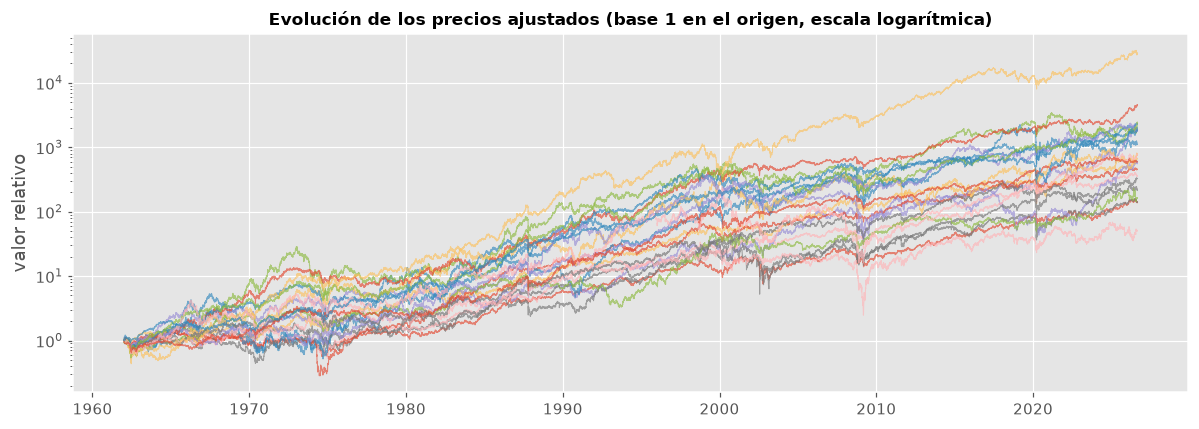

In [4]:
precios = datos.cargar_precios()

print(f"Universo final: {precios.shape[1]} activos")
print(f"Sesiones: {precios.shape[0]}")
print(f"Periodo: {precios.index.min().date()} a {precios.index.max().date()}")
print(f"\nComposición: {', '.join(precios.columns)}")

fig, ax = plt.subplots(figsize=(11, 4))
normalizado = precios / precios.iloc[0]
for columna in normalizado.columns:
    ax.plot(normalizado.index, normalizado[columna], linewidth=0.7, alpha=0.65)
ax.set_yscale("log")
ax.set_title("Evolución de los precios ajustados (base 1 en el origen, escala logarítmica)")
ax.set_ylabel("valor relativo")
fig.tight_layout()
graficos.guardar(fig, "00_precios_normalizados")
plt.show()

## 3. Paso a rentabilidades logarítmicas

El nivel de precios no es estacionario y su escala difiere en varios ordenes de
magnitud entre activos, de modo que no resulta utilizable directamente como
entrada de una red. Se trabaja con rentabilidades logarítmicas diarias, que son
aproximadamente estacionarias, aditivas en el tiempo y comparables entre series.

In [5]:
returns_bruto = datos.calcular_rentabilidades(precios)

print(f"Matriz de rentabilidades: {returns_bruto.shape}")
print(f"Valores ausentes restantes: {int(returns_bruto.isna().sum().sum())}")
print("\nEstadisticos descriptivos (agregado de todos los activos):")
descriptivos = pd.Series({
    "media diaria": returns_bruto.values.mean(),
    "desviación tipica": returns_bruto.values.std(),
    "mínimo": returns_bruto.values.min(),
    "máximo": returns_bruto.values.max(),
    "asimetría": float(pd.Series(returns_bruto.values.ravel()).skew()),
    "curtosis": float(pd.Series(returns_bruto.values.ravel()).kurt()),
})
display(descriptivos.to_frame("valor").round(4))

Matriz de rentabilidades: (16270, 23)
Valores ausentes restantes: 0

Estadisticos descriptivos (agregado de todos los activos):


,valor
media diaria,0.0004
desviación tipica,0.0172
mínimo,-0.5483
máximo,0.4884
asimetría,-0.4018
curtosis,19.4077


## 4. Limpieza de registros anomalos

Una curtosis de varios cientos indica presencia de valores extremos muy alejados
del cuerpo de la distribución. Parte de ellos corresponde a episodios reales de
mercado, como la sesión de octubre de 1987, y debe conservarse porque constituye
precisamente el fenomeno que se pretende modelar. Otra parte procede de errores
de ajuste por splits o dividendos y produce saltos que ningún activo cotizado
experimenta en una sola sesión.

Se adopta un criterio conservador: los movimientos que superan doce desviaciones
tipicas se recortan al limite en lugar de eliminarse. El recorte preserva el
signo y el caracter extremo del movimiento, impide que un único registro
erroneo domine la escala de la serie y no reduce el número de observaciones.

Observaciones recortadas: 39 de 374210 (0.0104 %)


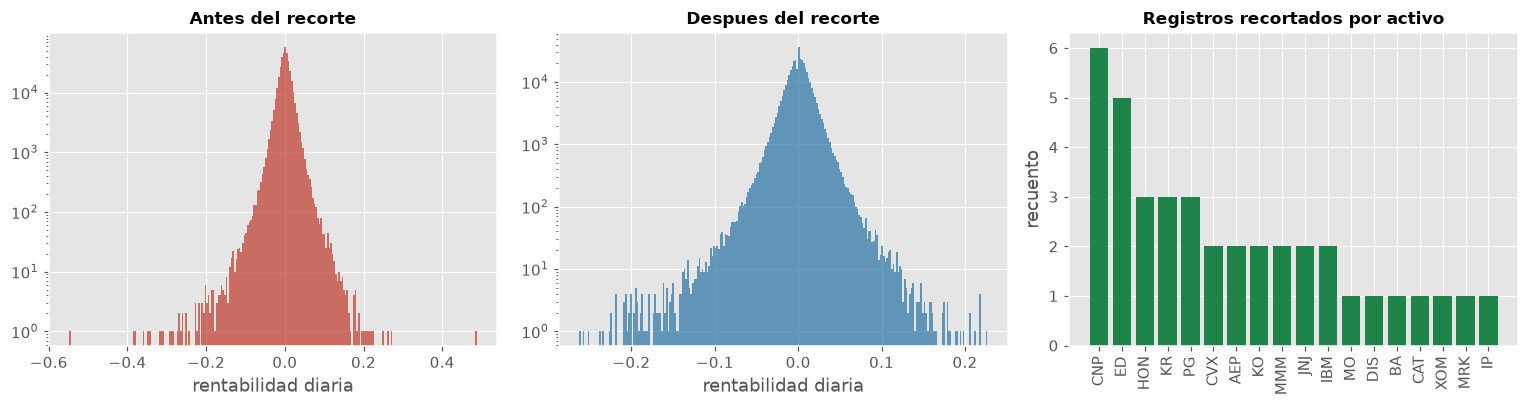

In [6]:
returns, n_recortes = datos.limpiar_rentabilidades(returns_bruto)

print(f"Observaciones recortadas: {n_recortes} de {returns.size} "
      f"({100 * n_recortes / returns.size:.4f} %)")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

axes[0].hist(returns_bruto.values.ravel(), bins=250, color="#c0392b", alpha=0.7)
axes[0].set_yscale("log")
axes[0].set_title("Antes del recorte")
axes[0].set_xlabel("rentabilidad diaria")

axes[1].hist(returns.values.ravel(), bins=250, color="#2874a6", alpha=0.7)
axes[1].set_yscale("log")
axes[1].set_title("Despues del recorte")
axes[1].set_xlabel("rentabilidad diaria")

extremos = (returns_bruto.abs() > 12 * returns_bruto.std()).sum().sort_values(ascending=False)
extremos = extremos[extremos > 0]
if len(extremos) > 0:
    axes[2].bar(extremos.index, extremos.values, color="#1e8449")
    axes[2].tick_params(axis="x", rotation=90)
axes[2].set_title("Registros recortados por activo")
axes[2].set_ylabel("recuento")

fig.tight_layout()
graficos.guardar(fig, "00_limpieza_outliers")
plt.show()

## 5. Definición de la variable objetivo

La cartera de referencia es la equiponderada del universo, cuya rentabilidad
diaria es la media transversal de las rentabilidades individuales. Sobre ella se
mide, para cada fecha, el **drawdown máximo de los treinta días siguientes**:
se reconstruye la trayectoria acumulada del horizonte futuro y se localiza la
mayor caída desde su propio máximo móvil.

Esta magnitud describe la peor pérdida encadenada que habria soportado un
inversor que entrase en esa fecha, y resulta más informativa que la rentabilidad
acumulada del periodo, que puede ser positiva aun habiendo atravesado un
retroceso considerable.

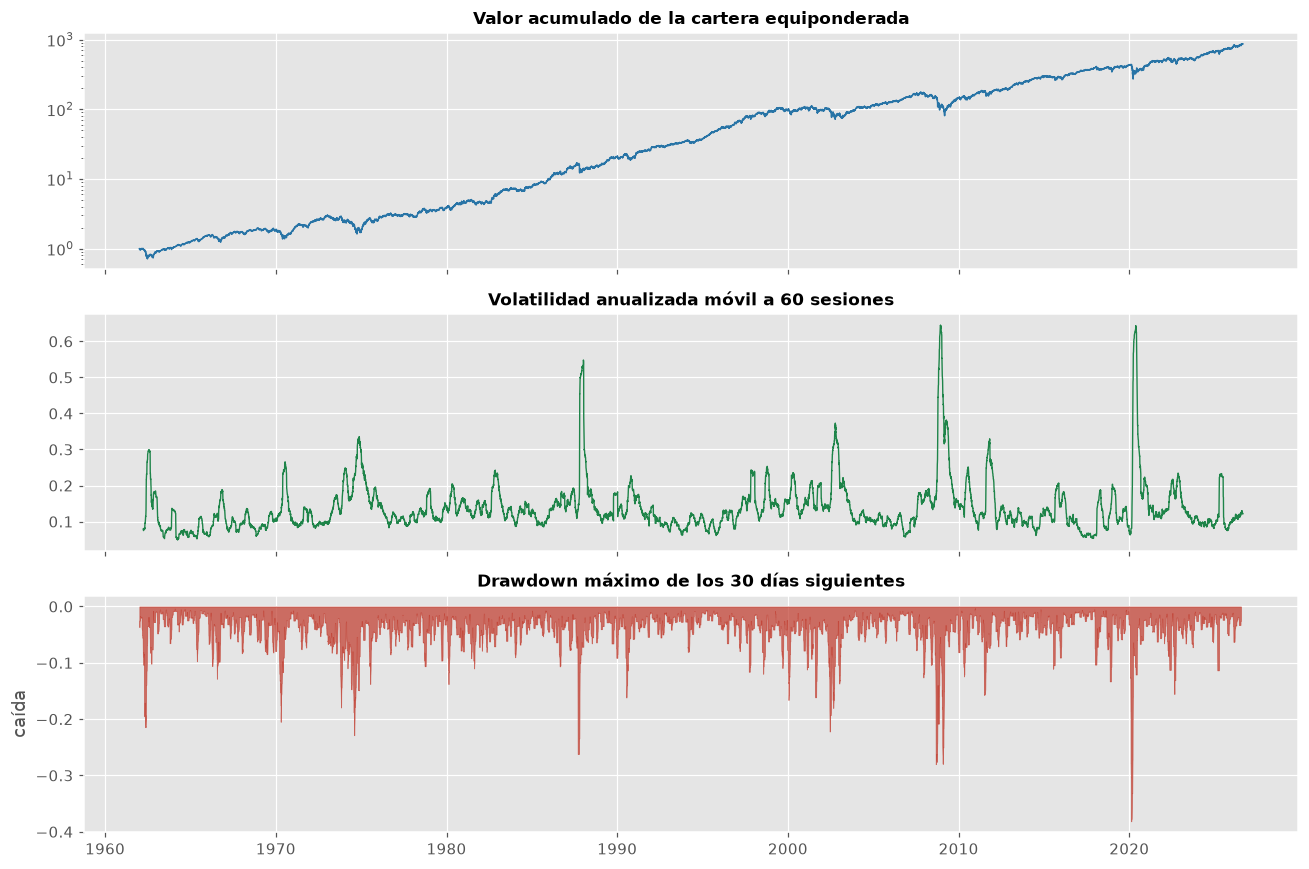

Drawdown futuro: mínimo -0.381, mediana -0.034, máximo -0.003


In [7]:
ret_mercado = datos.serie_mercado(returns)
dd_futuro = datos.drawdown_futuro(ret_mercado)

valor_cartera = np.exp(ret_mercado.cumsum())
volatilidad = ret_mercado.rolling(60).std() * np.sqrt(252)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(valor_cartera.index, valor_cartera.values, color="#2874a6", linewidth=1)
axes[0].set_yscale("log")
axes[0].set_title("Valor acumulado de la cartera equiponderada")

axes[1].plot(volatilidad.index, volatilidad.values, color="#1e8449", linewidth=0.9)
axes[1].set_title("Volatilidad anualizada móvil a 60 sesiones")

axes[2].fill_between(dd_futuro.index, dd_futuro.values, color="#c0392b", alpha=0.7)
axes[2].set_title("Drawdown máximo de los 30 días siguientes")
axes[2].set_ylabel("caída")

fig.tight_layout()
graficos.guardar(fig, "00_serie_mercado_drawdown")
plt.show()

print(f"Drawdown futuro: mínimo {dd_futuro.min():.3f}, "
      f"mediana {dd_futuro.median():.3f}, máximo {dd_futuro.max():.3f}")

## 6. Construcción de las ventanas

Cada observación del conjunto queda definida por una ventana de sesenta sesiones
consecutivas de rentabilidades de los veintitres activos, con forma
`(60, 23)`, y por el drawdown de los treinta días posteriores a esa ventana.

La separación temporal es estricta: ninguna sesión empleada como entrada
pertenece al horizonte sobre el que se mide la etiqueta. La entrada observa
exclusivamente el pasado.

In [8]:
X, dd_ventanas, fechas = datos.construir_ventanas(returns, dd_futuro)

print(f"Tensor de entrada X: {X.shape}  (ventanas, sesiones, activos)")
print(f"Drawdown asociado:   {dd_ventanas.shape}")
print(f"Primera ventana: {fechas.min().date()}   última ventana: {fechas.max().date()}")
print(f"Dimensión de una ventana aplanada: {X.shape[1] * X.shape[2]}")

Tensor de entrada X: (16180, 60, 23)  (ventanas, sesiones, activos)
Drawdown asociado:   (16180,)
Primera ventana: 1962-03-29   última ventana: 2026-07-15
Dimensión de una ventana aplanada: 1380


## 7. Partición cronologica con embargo

Un reparto aleatorio de las ventanas sería inadecuado en este contexto. Dos
ventanas separadas por un solo día comparten cincuenta y nueve de sus sesenta
sesiones, de manera que un reparto al azar situaria observaciones prácticamente
identicas a ambos lados de la frontera y produciria metricas artificialmente
altas que no anticipan el comportamiento real del modelo.

Se emplea por tanto una partición en bloques temporales consecutivos y se
descarta un tramo de noventa sesiones entre bloques. Ese hueco equivale a la
suma de la ventana de entrada y del horizonte de la etiqueta, con lo que ninguna
sesión de mercado puede influir simultáneamente en dos particiones distintas.

,partición,ventanas,desde,hasta
0,train,11326,1962-03-29,2007-03-28
1,validación,2337,2007-08-07,2016-11-14
2,test,2337,2017-03-28,2026-07-15


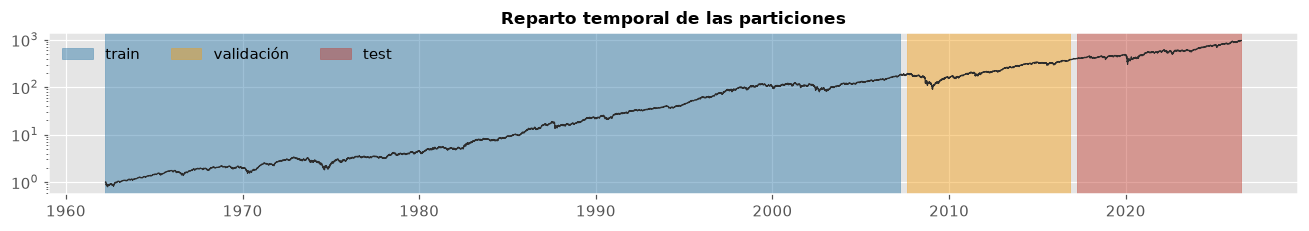

Sesiones descartadas por embargo entre bloques: 90


In [9]:
idx_train, idx_val, idx_test = datos.particion_temporal(len(X))

resumen_split = pd.DataFrame([
    {"partición": nombre,
     "ventanas": len(idx),
     "desde": fechas[idx].min().date(),
     "hasta": fechas[idx].max().date()}
    for nombre, idx in [("train", idx_train), ("validación", idx_val), ("test", idx_test)]
])
display(resumen_split)

fig, ax = plt.subplots(figsize=(12, 2.2))
colores = {"train": "#2874a6", "validación": "#f39c12", "test": "#c0392b"}
for nombre, idx in [("train", idx_train), ("validación", idx_val), ("test", idx_test)]:
    ax.axvspan(fechas[idx].min(), fechas[idx].max(), color=colores[nombre],
               alpha=0.45, label=nombre)
ax.plot(fechas, np.exp(np.cumsum(ret_mercado.values[-len(fechas):])),
        color="#2c2c2c", linewidth=0.8)
ax.set_yscale("log")
ax.set_title("Reparto temporal de las particiones")
ax.legend(ncol=3, loc="upper left")
fig.tight_layout()
graficos.guardar(fig, "00_particion_temporal")
plt.show()

print(f"Sesiones descartadas por embargo entre bloques: {config.EMBARGO}")

## 8. Calibración del umbral y etiquetado

El umbral que separa un retroceso ordinario de un episodio severo se fija como
el cuantil del diez por ciento de la distribución de drawdown **calculada
únicamente sobre el bloque de entrenamiento**. Calibrarlo sobre la muestra
completa trasladaria información del periodo de test a la propia definición del
problema.

La proporción de positivos resultante en validación y test no es exactamente del
diez por ciento, y esa discrepancia es informativa: refleja que la frecuencia de
episodios de estrés varia entre decadas, de modo que el modelo se enfrenta en
test a una distribución que no coincide con la que ha visto al entrenar.

Umbral de drawdown severo: -7.91 %


,partición,ventanas,positivos,tasa de positivos
0,train,11326,1137,0.1004
1,validación,2337,299,0.1279
2,test,2337,243,0.1040


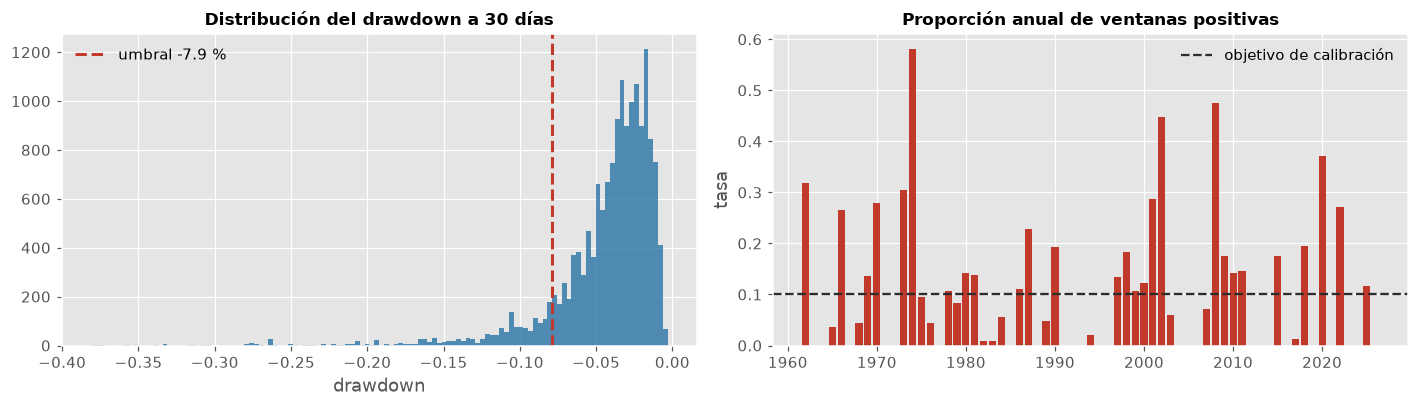

In [10]:
umbral_dd = datos.calibrar_umbral(dd_ventanas[idx_train])
y = datos.etiquetar(dd_ventanas, umbral_dd)

print(f"Umbral de drawdown severo: {100 * umbral_dd:.2f} %")

tabla_clases = pd.DataFrame([
    {"partición": nombre,
     "ventanas": len(idx),
     "positivos": int(y[idx].sum()),
     "tasa de positivos": round(float(y[idx].mean()), 4)}
    for nombre, idx in [("train", idx_train), ("validación", idx_val), ("test", idx_test)]
])
display(tabla_clases)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

axes[0].hist(dd_ventanas, bins=120, color="#2874a6", alpha=0.8)
axes[0].axvline(umbral_dd, color="#c0392b", linestyle="--", linewidth=2,
                label=f"umbral {100 * umbral_dd:.1f} %")
axes[0].set_title("Distribución del drawdown a 30 días")
axes[0].set_xlabel("drawdown")
axes[0].legend()

positivos_anuales = pd.Series(y, index=fechas).resample("YE").mean()
axes[1].bar(positivos_anuales.index.year, positivos_anuales.values, color="#c0392b")
axes[1].axhline(config.PROPORCION_POSITIVOS, color="#2c2c2c", linestyle="--",
                label="objetivo de calibración")
axes[1].set_title("Proporción anual de ventanas positivas")
axes[1].set_ylabel("tasa")
axes[1].legend()

fig.tight_layout()
graficos.guardar(fig, "00_etiqueta_drawdown")
plt.show()

## 9. Escalado

Los generadores del proyecto cierran con activación `tanh`, cuyo recorrido es el
intervalo `[-1, 1]`. Para que el rango de salida del generador coincida con el
de los datos se aplica una transformación en dos pasos: estandarización por
activo y división por cuatro desviaciones tipicas, con recorte posterior al
intervalo unidad.

Una normalización por mínimo y máximo sería inservible aquí, porque una única
sesión extrema comprimiria el resto de la distribución en un entorno minusculo
alrededor de cero. Los parametros se estiman **solo con el bloque de
entrenamiento** y se aplican sin recalcular al resto.

Rango tras el escalado: [-1.000, 1.000]
Fracción de valores saturados en los extremos: 0.542 %


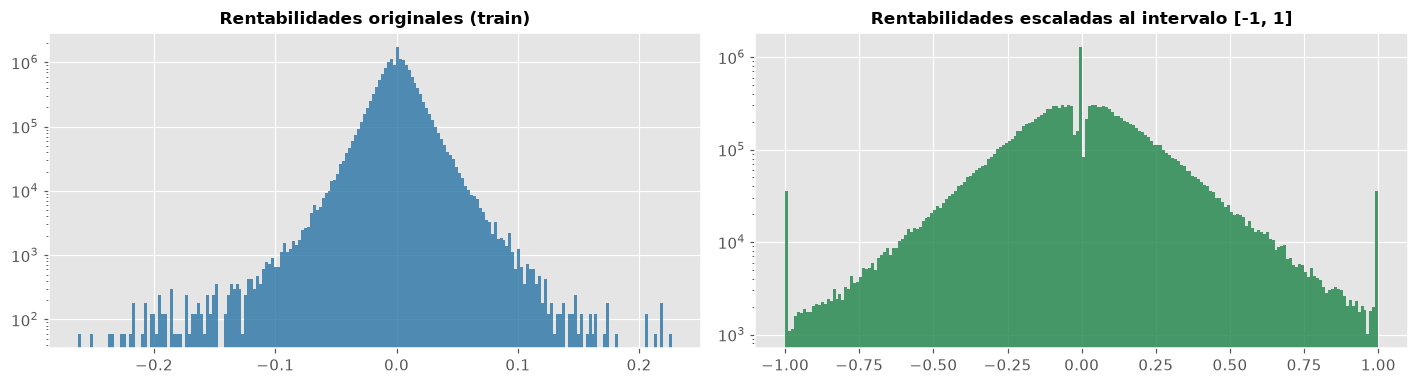

In [11]:
escalador = datos.EscaladorTanh().ajustar(X[idx_train])
X_esc = escalador.transformar(X)

frac_saturada = float((np.abs(X_esc) >= 0.999).mean())
print(f"Rango tras el escalado: [{X_esc.min():.3f}, {X_esc.max():.3f}]")
print(f"Fracción de valores saturados en los extremos: {100 * frac_saturada:.3f} %")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].hist(X[idx_train].ravel(), bins=200, color="#2874a6", alpha=0.8)
axes[0].set_yscale("log")
axes[0].set_title("Rentabilidades originales (train)")

axes[1].hist(X_esc[idx_train].ravel(), bins=200, color="#1e8449", alpha=0.8)
axes[1].set_yscale("log")
axes[1].set_title("Rentabilidades escaladas al intervalo [-1, 1]")

fig.tight_layout()
graficos.guardar(fig, "00_escalado")
plt.show()

## 10. Persistencia del dataset

El conjunto se almacena en un único fichero comprimido. Todos los notebooks
posteriores parten de el, de modo que ninguno vuelve a tocar los precios ni
repite la definición del problema. Se guardan también los parametros del
escalador, imprescindibles para devolver los datos sinteticos a la escala
original cuando se quiera interpretarlos.

In [12]:
datos.guardar_dataset(
    config.RUTA_DATASET,
    X_train=X_esc[idx_train], y_train=y[idx_train],
    X_val=X_esc[idx_val], y_val=y[idx_val],
    X_test=X_esc[idx_test], y_test=y[idx_test],
    dd_train=dd_ventanas[idx_train],
    dd_val=dd_ventanas[idx_val],
    dd_test=dd_ventanas[idx_test],
    fechas_train=fechas[idx_train].strftime("%Y-%m-%d").values.astype("U10"),
    fechas_val=fechas[idx_val].strftime("%Y-%m-%d").values.astype("U10"),
    fechas_test=fechas[idx_test].strftime("%Y-%m-%d").values.astype("U10"),
    tickers=np.array(precios.columns, dtype=object),
    umbral_dd=np.array(umbral_dd),
    escalador_media=escalador.media_,
    escalador_escala=escalador.escala_,
    escalador_n_sigmas=np.array(escalador.n_sigmas),
)

print(f"Dataset guardado en {config.RUTA_DATASET}")
print(f"Tamaño en disco: {os.path.getsize(config.RUTA_DATASET) / 1e6:.1f} MB")

print("\nResumen del conjunto generado")
print(f"  entrada          {X_esc.shape[1]} sesiones x {X_esc.shape[2]} activos")
print(f"  train            {len(idx_train)} ventanas, {y[idx_train].mean():.1%} positivas")
print(f"  validación       {len(idx_val)} ventanas, {y[idx_val].mean():.1%} positivas")
print(f"  test             {len(idx_test)} ventanas, {y[idx_test].mean():.1%} positivas")
print(f"  umbral drawdown  {100 * umbral_dd:.2f} %")

Dataset guardado en C:\Users\raulr\Documents\MIAX\Practicas\B5-T1\data\processed\dataset.npz
Tamaño en disco: 2.1 MB

Resumen del conjunto generado
  entrada          60 sesiones x 23 activos
  train            11326 ventanas, 10.0% positivas
  validación       2337 ventanas, 12.8% positivas
  test             2337 ventanas, 10.4% positivas
  umbral drawdown  -7.91 %


## Conclusiones del notebook

El conjunto de trabajo esta formado por ventanas de sesenta sesiones sobre
veintitres activos con historia completa desde 1962, etiquetadas según sufran o
no un retroceso superior al umbral calibrado durante los treinta días
siguientes.

Tres decisiones condicionan todo lo que sigue y conviene tenerlas presentes al
interpretar los resultados:

1. **La partición es cronologica y con embargo.** Las metricas de test miden la
   capacidad del modelo sobre un periodo posterior al de entrenamiento, que es
   la situación real de uso. Un reparto aleatorio habria arrojado cifras mucho
   más favorables pero carentes de significado.
2. **El umbral se calibra solo con el entrenamiento.** La proporción de
   positivos difiere entre particiones porque la frecuencia de los episodios de
   estrés cambia con el tiempo.
3. **La clase de interés es minoritaria.** Aproximadamente una de cada diez
   ventanas es positiva, de modo que la tasa de acierto global carece de valor
   como criterio y la evaluación se apoya en el area bajo la curva de precisión
   y exhaustividad.

El análisis exploratorio detallado de estos datos se desarrolla en el notebook
`01_analisis_exploratorio.ipynb`.